# Tarea 3

Nombre: Francico Gonzalez

Carnet: 24002914

# Importacion de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from IPython.display import display
from dateutil import parser
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from kmodes.kprototypes import KPrototypes
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif



 # Carga de datos y exploracion inicial

In [2]:
# --Carga de datos ---
data = pd.read_csv("pacientes_nutricion.csv")

In [3]:
#funcion para explorar el dataframe
def explorar_dataframe(df):
    print("Tipos de datos del DataFrame:")
    display(df.dtypes.to_frame(name='Tipo de dato'))

    print("Descripcion inicial de los datos:")
    display(df.describe(include='all').T)

    print("Distribucion inicial de variables numericas:")
    df.select_dtypes(include='number').hist(figsize=(12, 8))
    plt.tight_layout()
    plt.show()

    print("Distribucion de las variables categoricas:")
    categorical_columns = df.select_dtypes(include=['object', 'category', 'string','bool']).columns
    for col in categorical_columns:
        plt.figure(figsize=(10,  5))
        sns.countplot(x=col, data=df.dropna(), color='skyblue')
        plt.title(f'Distribucion de {col}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=45)
        plt.show()

    columnas_fecha = df.select_dtypes(include=['datetime64[ns]']).columns
    estadisticas_fechas = []
    for col in columnas_fecha:
        serie = df[col]
        stats = {
            'columna': col,
            'no nulos': serie.notnull().sum(),
            'nulos': serie.isnull().sum(),
            'min': serie.min(),
            'max': serie.max(),
            'rango (dias)': (serie.max() - serie.min()).days if pd.notnull(serie.min()) and pd.notnull(serie.max()) else None,
            'valores unicos': serie.nunique()
        }
        estadisticas_fechas.append(stats)
    print("Estadisticas para columnas de tipo fecha:")
    display(pd.DataFrame(estadisticas_fechas))


Tipos de datos del DataFrame:


,Tipo de dato
id_paciente,int64
sexo,object
edad,float64
peso_kg,float64
altura_cm,float64
IMC,float64
grasa_corporal_pct,float64
masa_muscular_pct,float64
nivel_actividad,object
dias_ejercicio_semana,int64


Descripcion inicial de los datos:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_paciente,1500.0,NaN,NaN,NaN,750.5,433.157015,1.0,375.75,750.5,1125.25,1500.0
sexo,1500,6,Female,268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,1483.0,NaN,NaN,NaN,48.406608,32.122675,-5.0,20.0,48.0,78.0,104.0
peso_kg,1500.0,NaN,NaN,NaN,70.901333,15.027302,19.7,60.7,71.05,81.025,117.5
altura_cm,1500.0,NaN,NaN,NaN,169.9638,10.027143,136.1,162.9,169.75,177.0,205.0
IMC,1365.0,NaN,NaN,NaN,25.135759,5.018015,9.341281,21.712097,25.163273,28.574079,39.219737
grasa_corporal_pct,1500.0,NaN,NaN,NaN,25.133067,9.694352,5.0,18.2,25.1,31.7,59.1
masa_muscular_pct,1500.0,NaN,NaN,NaN,34.971867,16.246383,-16.4,23.7,34.8,44.8,137.8
nivel_actividad,1500,6,Bajo,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dias_ejercicio_semana,1500.0,NaN,NaN,NaN,4.418,2.855996,0.0,2.0,4.0,7.0,9.0


Distribucion inicial de variables numericas:


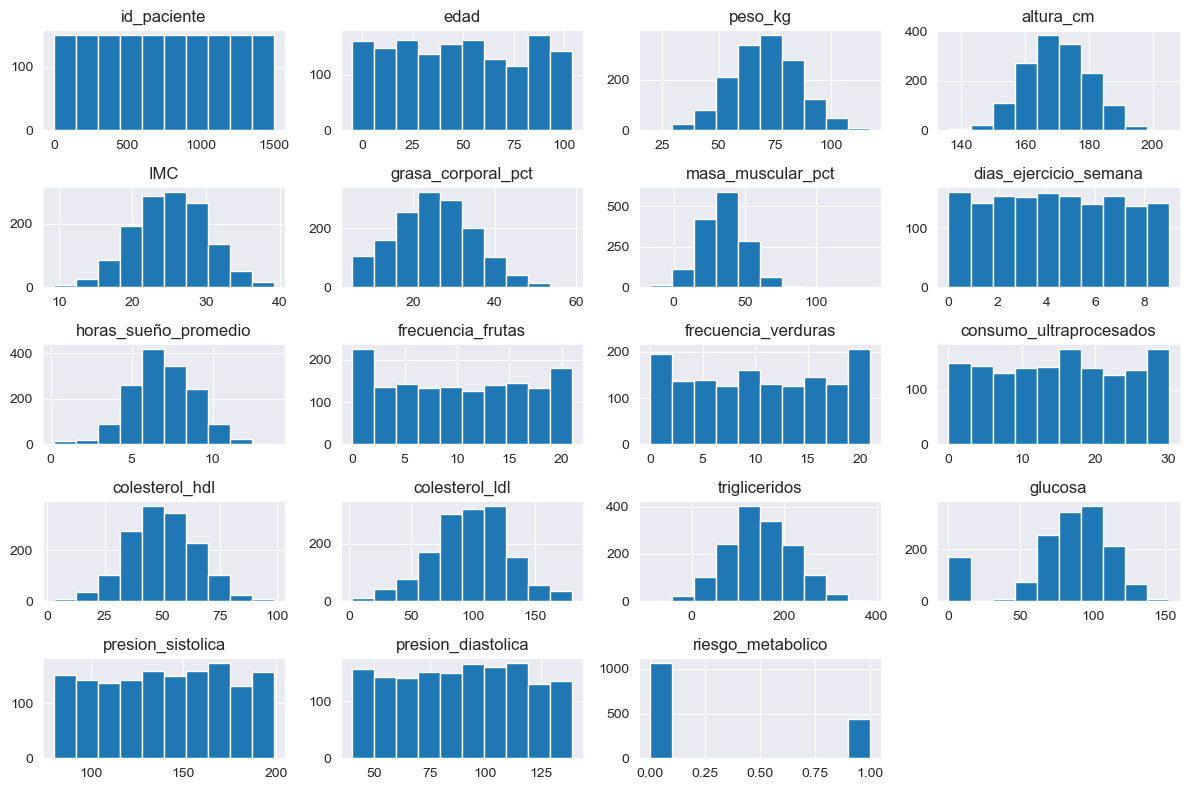

Distribucion de las variables categoricas:


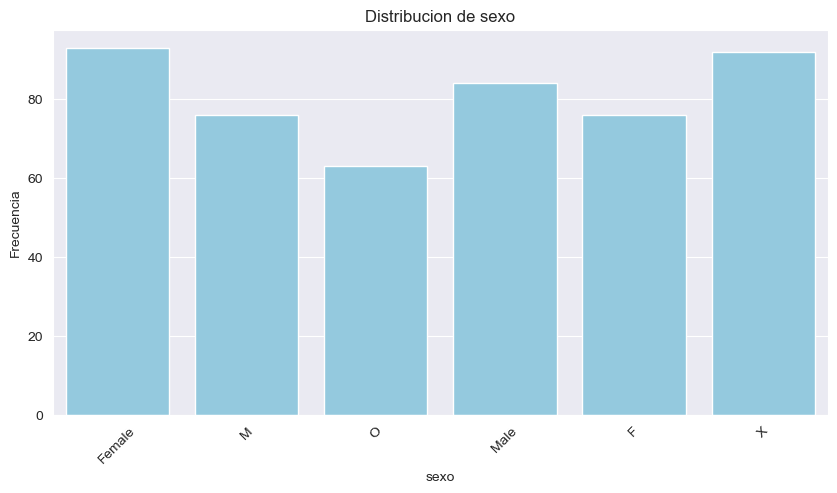

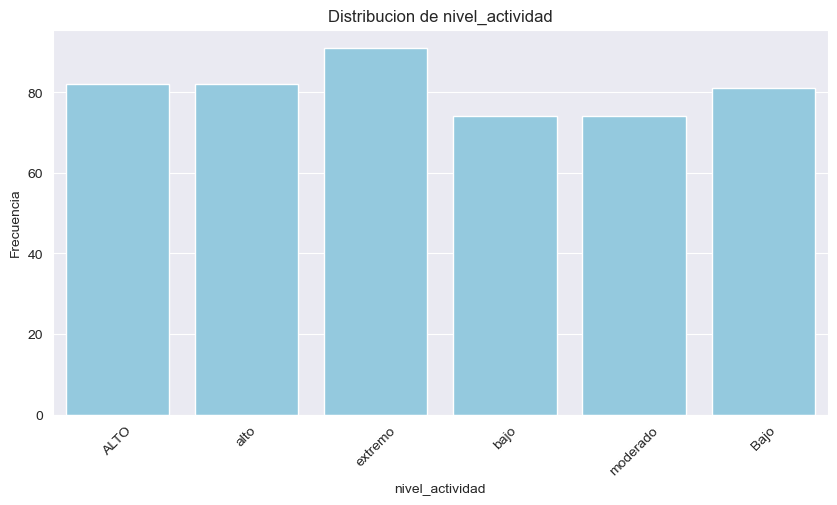

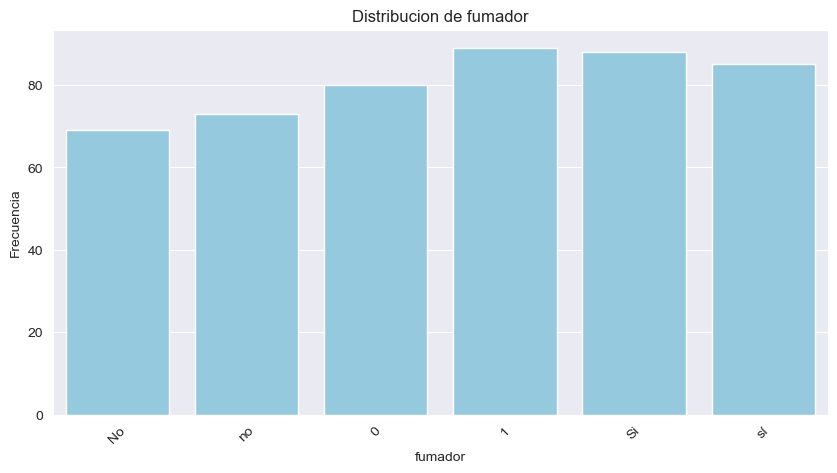

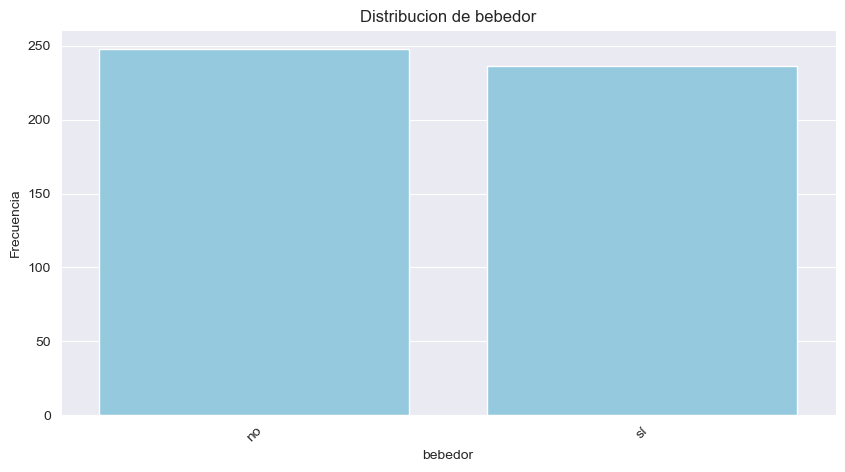

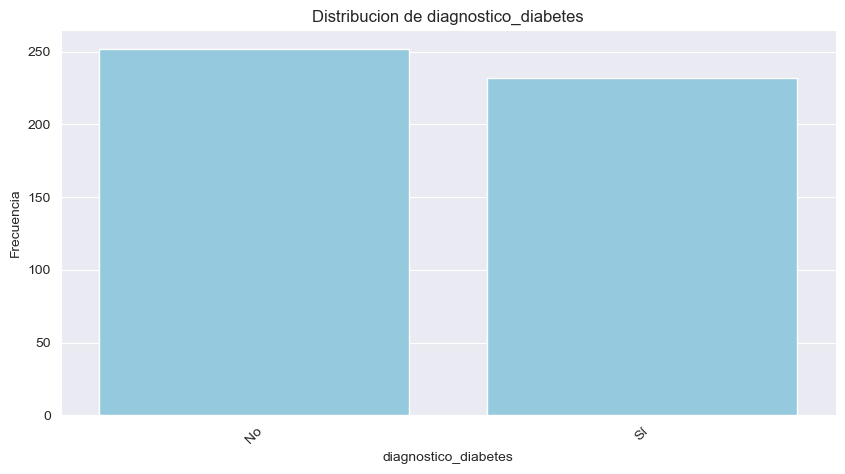

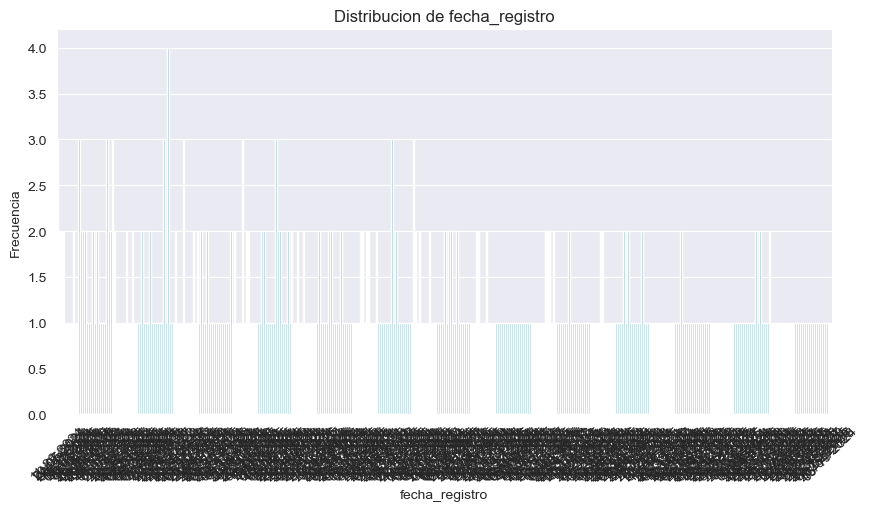

Estadisticas para columnas de tipo fecha:


""


In [4]:
explorar_dataframe(data)

# Transformación del dataframe usando pipelines

In [5]:
#funciones para transformacion
def parse_fecha(fecha):
    try:
        return parser.parse(fecha, dayfirst=True)
    except:
        try:
            return parser.parse(fecha, dayfirst=False)
        except:
            return pd.NaT


#Limpieza y conversión de tipos
class TipoTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        tipos = {
            'fecha_registro': 'datetime64[ns]',
            'edad': 'Int64',
            'peso': 'float',
            'talla': 'float',
            'imc': 'float',
            'hdl': 'float',
            'trigliceridos': 'float',
            'glucosa': 'float',
            'diagnostico': 'string',
            'nombre': 'string',
            'id': 'string'
        }
        for col, tipo in tipos.items():
            if col in df.columns:
                if "datetime" in str(tipo):
                    df[col] = df[col].apply(parse_fecha)
                    df[col] = pd.to_datetime(df[col], errors='coerce')
                    print(f"Columna {col} convertida a tipo {tipo}")
                else:
                    try:
                        df[col] = df[col].astype(tipo)
                        print(f"Columna {col} convertida a tipo {tipo}")
                    except:
                        pass
        return df

# Normalizaciónes

def normalizar_binarios(df):
    df = df.copy()
    mapeo = {'si': True, 'sí': True, '1': True, 'no': False, '0': False}
    for col in ['fumador', 'bebedor', 'diagnostico_diabetes', 'riesgo_metabolico']:
        aux = df[col].astype(str).str.lower().str.strip()
        df[col] = aux.map(mapeo).astype('boolean')
        print(f"Columna {col} normalizada")
    return df

def normalizar_sexo(df):
    df = df.copy()
    mapeo = {'Female': 'Female', 'F': 'Female', 'O': 'Other', 'X': 'Unknown', 'Male': 'Male','M': 'Male'}

    df['sexo'] = df['sexo'].map(mapeo)
    print("Columna sexo normalizada")
    return df

def normalizar_varios(df):
    df = df.copy()
    df['nivel_actividad'] = df['nivel_actividad'].astype(str).str.lower().str.strip()
    columnas_numericas = df.select_dtypes(include=['float', 'int']).columns
    for col in columnas_numericas:
        # asignar valor absoluto
        df[col] = df[col].abs()
        print(f"Columna {col} normalizada")
    columnas_cero_nan = ['edad','glucosa']
    for col in columnas_cero_nan:
        # asignar NaN a los valores cero
        df[col] = df[col].replace(0, np.nan)
        print(f"Columna {col} normalizada")
    return df





In [6]:
#asignacion de transformers
binario_transformer = FunctionTransformer(normalizar_binarios)
sex_transformer = FunctionTransformer(normalizar_sexo)
varios_transformer = FunctionTransformer(normalizar_varios)

# Pipeline completo
data_pipeline = Pipeline([
    ("tipos", TipoTransformer()),
    ("binarios", binario_transformer),
    ("sexo", sex_transformer),
    ("varios", varios_transformer),
])

# Aplicar pipeline
data_tratada = data_pipeline.fit_transform(data)


Columna fecha_registro convertida a tipo datetime64[ns]
Columna edad convertida a tipo Int64
Columna trigliceridos convertida a tipo float
Columna glucosa convertida a tipo float
Columna fumador normalizada
Columna bebedor normalizada
Columna diagnostico_diabetes normalizada
Columna riesgo_metabolico normalizada
Columna sexo normalizada
Columna id_paciente normalizada
Columna edad normalizada
Columna peso_kg normalizada
Columna altura_cm normalizada
Columna IMC normalizada
Columna grasa_corporal_pct normalizada
Columna masa_muscular_pct normalizada
Columna dias_ejercicio_semana normalizada
Columna horas_sueño_promedio normalizada
Columna frecuencia_frutas normalizada
Columna frecuencia_verduras normalizada
Columna consumo_ultraprocesados normalizada
Columna colesterol_hdl normalizada
Columna colesterol_ldl normalizada
Columna trigliceridos normalizada
Columna glucosa normalizada
Columna presion_sistolica normalizada
Columna presion_diastolica normalizada
Columna edad normalizada
Column

Tipos de datos del DataFrame:


,Tipo de dato
id_paciente,int64
sexo,object
edad,Int64
peso_kg,float64
altura_cm,float64
IMC,float64
grasa_corporal_pct,float64
masa_muscular_pct,float64
nivel_actividad,object
dias_ejercicio_semana,int64


Descripcion inicial de los datos:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_paciente,1500.0,NaN,NaN,NaN,750.5,1.0,375.75,750.5,1125.25,1500.0,433.157015
sexo,1500,4,Female,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,1469.0,<NA>,<NA>,<NA>,49.242342,1.0,21.0,48.0,78.0,104.0,31.343093
peso_kg,1500.0,NaN,NaN,NaN,70.901333,19.7,60.7,71.05,81.025,117.5,15.027302
altura_cm,1500.0,NaN,NaN,NaN,169.9638,136.1,162.9,169.75,177.0,205.0,10.027143
IMC,1365.0,NaN,NaN,NaN,25.135759,9.341281,21.712097,25.163273,28.574079,39.219737,5.018015
grasa_corporal_pct,1500.0,NaN,NaN,NaN,25.133067,5.0,18.2,25.1,31.7,59.1,9.694352
masa_muscular_pct,1500.0,NaN,NaN,NaN,35.112667,0.1,23.7,34.8,44.8,137.8,15.939588
nivel_actividad,1500,4,alto,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dias_ejercicio_semana,1500.0,NaN,NaN,NaN,4.418,0.0,2.0,4.0,7.0,9.0,2.855996


Distribucion inicial de variables numericas:


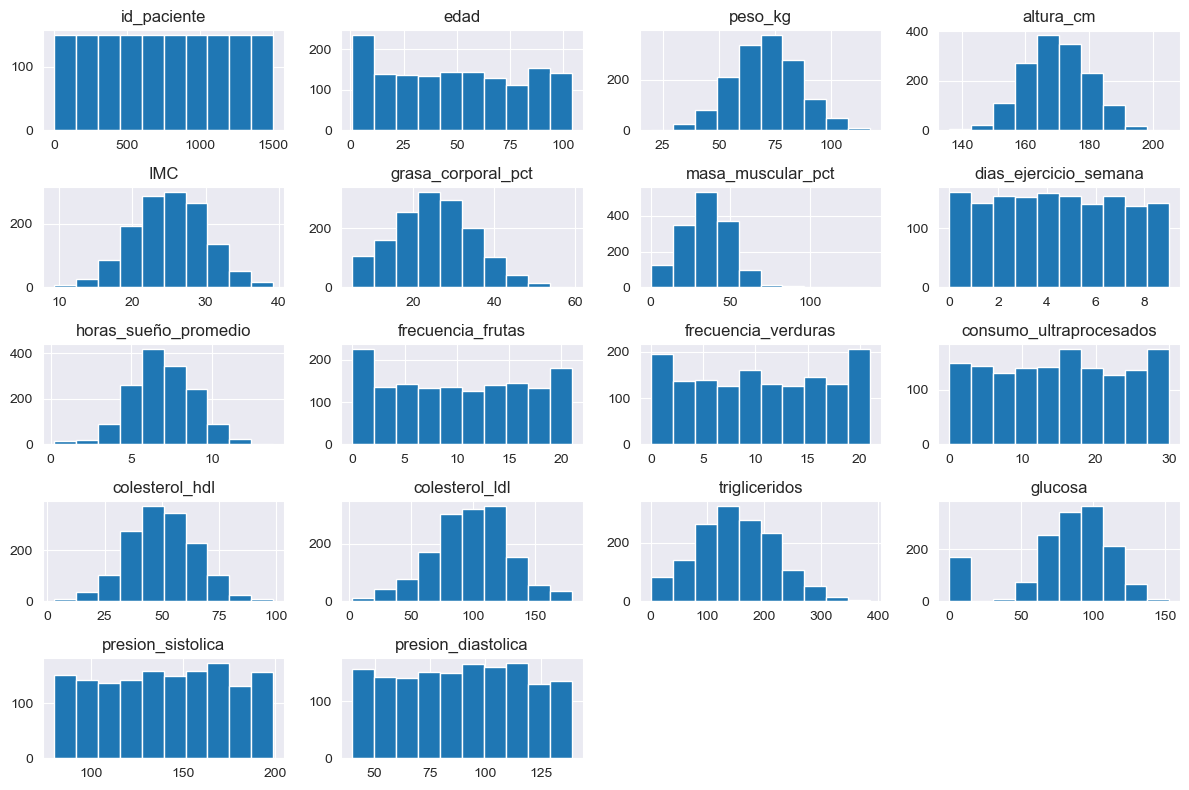

Distribucion de las variables categoricas:


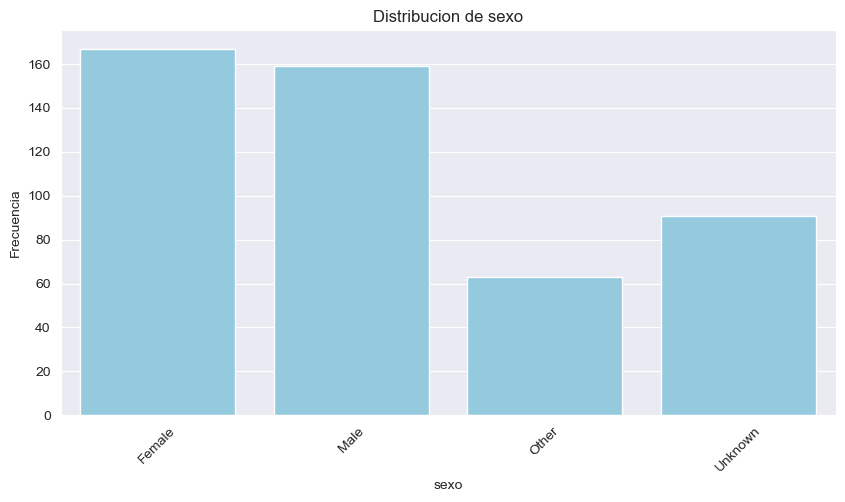

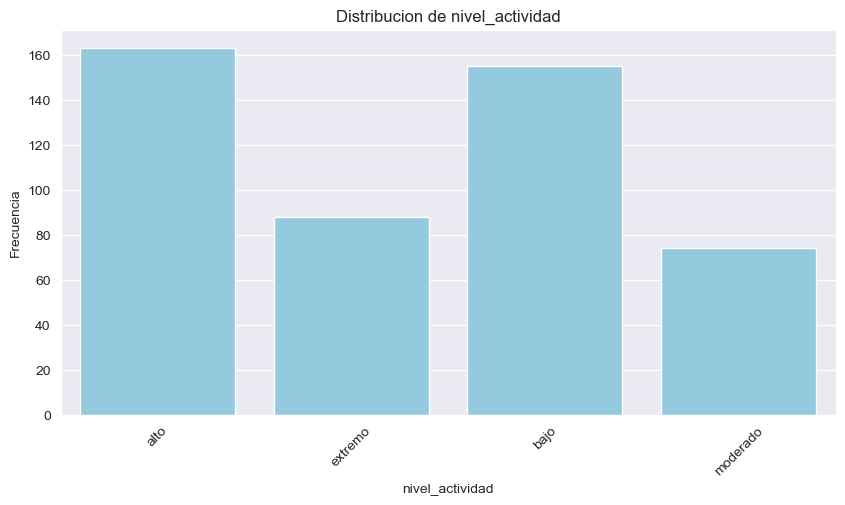

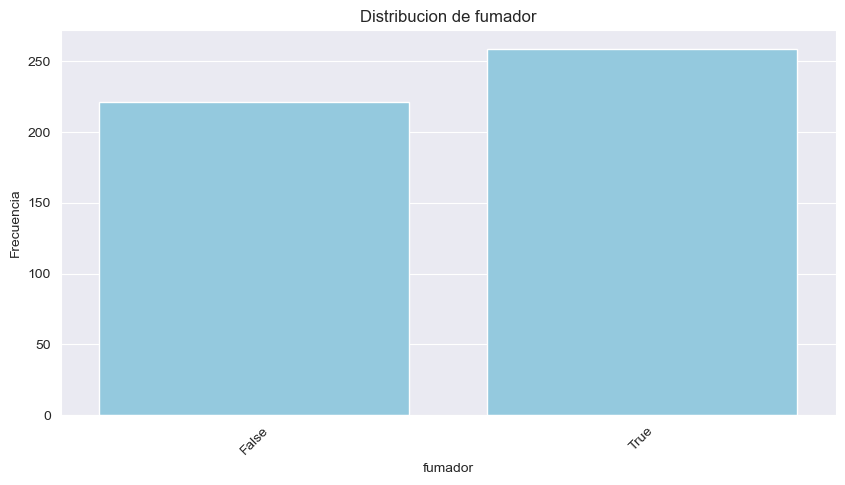

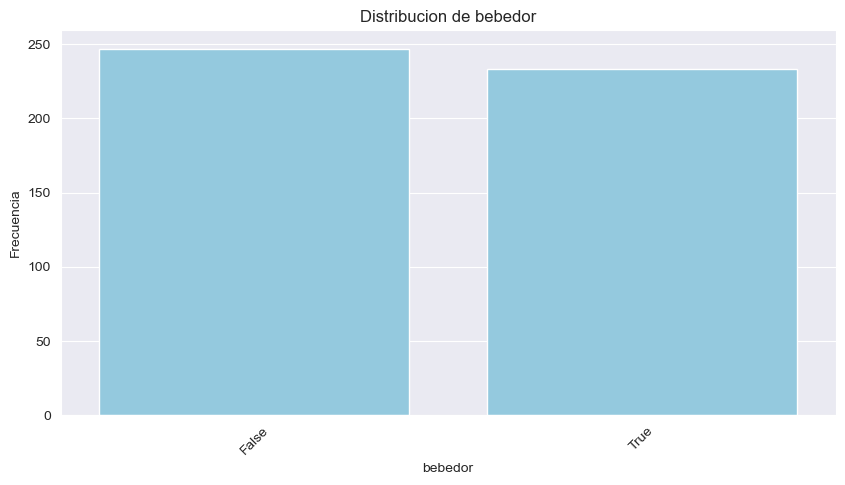

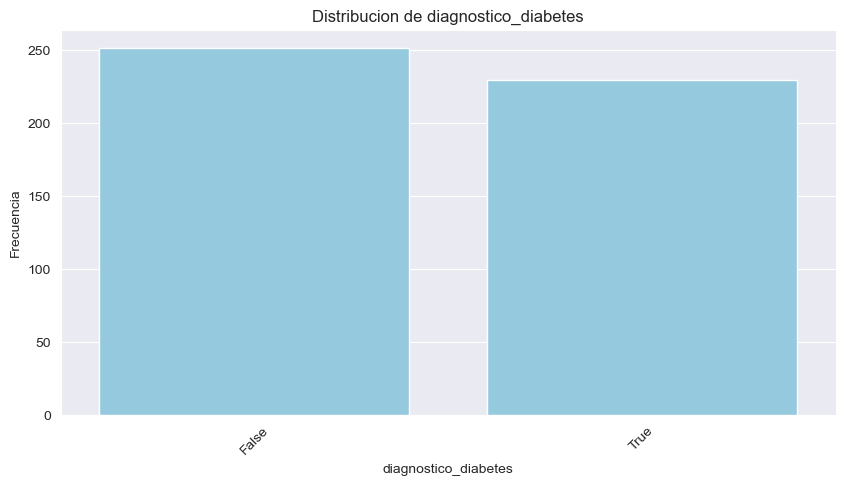

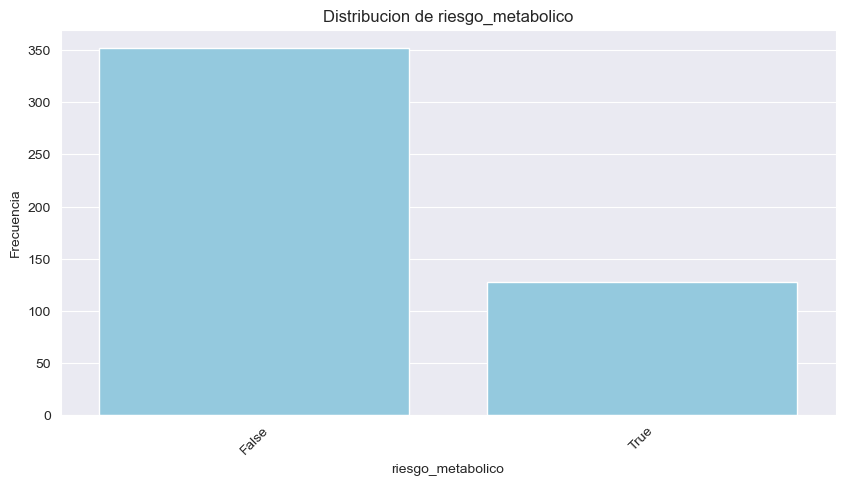

Estadisticas para columnas de tipo fecha:


,columna,no nulos,nulos,min,max,rango (dias),valores unicos
0,fecha_registro,1500,0,2024-01-06,2025-12-04,698,397


In [7]:
explorar_dataframe(data_tratada)

# Imputación de valores faltantes utilizando K-Prototypes

En este apartado se implementa una función personalizada llamada `imputar_por_kprototypes` que permite imputar valores faltantes en variables categóricas y numéricas de manera informada. El método se basa en el agrupamiento de los datos utilizando el algoritmo **K-Prototypes**, que es adecuado para datasets mixtos (con variables numéricas y categóricas).

El enfoque consiste en identificar primero las variables con menos valores faltantes, que son utilizadas como base para generar los grupos o clusters. De este modo, se evita el sesgo que podría introducirse al incluir variables con muchos nulos en el proceso de agrupamiento. Posteriormente, las variables con más valores faltantes se imputan por **la moda (en el caso de las categóricas)** y **la mediana (en el caso de las numéricas)** dentro de cada cluster.

Adicionalmente, la función selecciona de forma automática el número óptimo de clusters mediante el uso del **silhouette score**, e incluye una visualización opcional con PCA para evaluar la separación de los grupos generados.

Este enfoque permite preservar la coherencia entre variables al imputar valores faltantes, ya que toma en cuenta la estructura subyacente del conjunto de datos.


In [8]:
def imputar_por_kprototypes(data, columnas_cat_a_imputar, columnas_num_a_imputar, k_max=5, visualizar=True):
    print("Iniciando imputacion con K-Prototypes priorizando columnas con menos faltantes para agrupar...")

    df = data.copy()
    df_scaled = df.copy()

    df_scaled.drop(columns=['id_paciente', 'fecha_registro'], inplace=True, errors='ignore')

    todas_cat = df_scaled.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()
    todas_num = df_scaled.select_dtypes(include=[np.number]).columns.tolist()


    scaler = StandardScaler()
    df_scaled[todas_num] = scaler.fit_transform(df_scaled[todas_num])

    selector = VarianceThreshold(threshold=0.01)
    selector.fit(df_scaled[todas_num].drop(columns=columnas_num_a_imputar, errors='ignore'))
    columnas_num_filtradas = df_scaled[todas_num].drop(columns=columnas_num_a_imputar, errors='ignore').columns[selector.get_support()].tolist()

    columnas_prelim = columnas_num_filtradas + [col for col in todas_cat if col not in columnas_cat_a_imputar]

    df_clust = df[columnas_prelim].dropna()
    X = df_clust.to_numpy()
    cat_idxs = [columnas_prelim.index(col) for col in columnas_prelim if col in todas_cat]

    silhouette_scores = {}
    print("Calculando silhouette scores para seleccion de k...")
    for k in range(2, min(k_max + 1, len(df_clust))):
        modelo = KPrototypes(n_clusters=k, init='Cao', verbose=0, random_state=42)
        clusters = modelo.fit_predict(X, categorical=cat_idxs)
        try:
            X_num = df_clust[[col for col in columnas_prelim if col in todas_num]].to_numpy()
            score = silhouette_score(X_num, clusters)
            silhouette_scores[k] = score
            print(f"k = {k}: silhouette score = {score:.4f}")
        except:
            continue

    plt.figure(figsize=(8, 4))
    plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
    plt.title('Seleccion del numero optimo de clusters (Silhouette Score)')
    plt.xlabel('Numero de clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

    mejor_k = max(silhouette_scores, key=silhouette_scores.get)
    print(f"Numero optimo de clusters seleccionado: {mejor_k}")

    modelo_final = KPrototypes(n_clusters=mejor_k, init='Cao', verbose=0, random_state=42)
    clusters = modelo_final.fit_predict(X, categorical=cat_idxs)
    df_clust['cluster'] = clusters

    df['cluster'] = np.nan
    df.loc[df_clust.index, 'cluster'] = df_clust['cluster']

    print("Imputando variables categoricas por moda...")
    for col in columnas_cat_a_imputar:
        if col in df.columns and df[col].isnull().sum() > 0:
            for c in range(mejor_k):
                idx = df[(df['cluster'] == c) & df[col].notna()].index
                moda = df.loc[idx, col].mode()
                if not moda.empty:
                    idx_nulos = df[(df['cluster'] == c) & df[col].isna()].index
                    df.loc[idx_nulos, col] = moda[0]
                    print(f"Imputado '{col}' en cluster {c} con moda '{moda[0]}' en {len(idx_nulos)} filas")

    print("Imputando variables numericas por mediana...")
    for col in columnas_num_a_imputar:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col] = df[col].astype(float)
            for c in range(mejor_k):
                idx = df[(df['cluster'] == c) & df[col].notna()].index
                mediana = df.loc[idx, col].median()
                idx_nulos = df[(df['cluster'] == c) & df[col].isna()].index
                df.loc[idx_nulos, col] = mediana
                print(f"Imputado '{col}' en cluster {c} con mediana {mediana:.2f} en {len(idx_nulos)} filas")

    df_final = df.drop(columns='cluster')

    if visualizar and len(columnas_num_filtradas) >= 2:
        pca = PCA(n_components=2)
        pca_data = pca.fit_transform(df_clust[columnas_num_filtradas])
        plot_df = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
        plot_df['cluster'] = df_clust['cluster'].values

        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=plot_df, x='PCA1', y='PCA2', hue='cluster', palette='Set2', s=60)
        plt.title('Visualizacion de clusters con PCA')
        plt.xlabel('PCA 1')
        plt.ylabel('PCA 2')
        plt.legend(title='Cluster')
        plt.grid(True)
        plt.show()

    print("Imputacion completada.")
    return df_final


Iniciando imputacion con K-Prototypes priorizando columnas con menos faltantes para agrupar...
Calculando silhouette scores para seleccion de k...
k = 2: silhouette score = 0.2598
k = 3: silhouette score = 0.1609
k = 4: silhouette score = 0.1541
k = 5: silhouette score = 0.1625


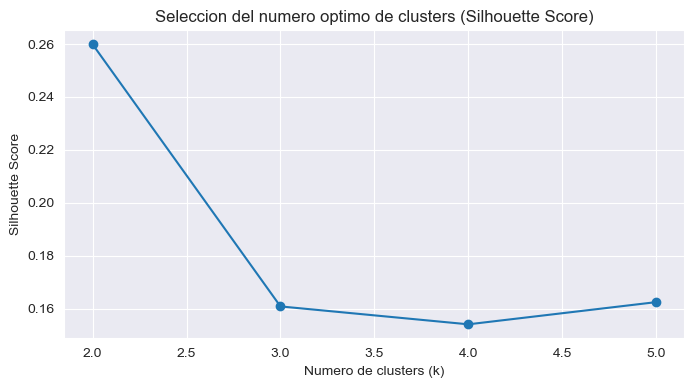

Numero optimo de clusters seleccionado: 2
Imputando variables categoricas por moda...
Imputado 'fumador' en cluster 0 con moda 'True' en 111 filas
Imputado 'fumador' en cluster 1 con moda 'False' en 112 filas
Imputado 'bebedor' en cluster 0 con moda 'True' en 227 filas
Imputado 'bebedor' en cluster 1 con moda 'True' en 303 filas
Imputado 'diagnostico_diabetes' en cluster 0 con moda 'False' en 213 filas
Imputado 'diagnostico_diabetes' en cluster 1 con moda 'False' en 278 filas
Imputando variables numericas por mediana...
Imputado 'edad' en cluster 0 con mediana 47.00 en 12 filas
Imputado 'edad' en cluster 1 con mediana 49.00 en 19 filas
Imputado 'IMC' en cluster 0 con mediana 25.36 en 67 filas
Imputado 'IMC' en cluster 1 con mediana 24.99 en 68 filas
Imputado 'consumo_ultraprocesados' en cluster 0 con mediana 15.00 en 29 filas
Imputado 'consumo_ultraprocesados' en cluster 1 con mediana 15.00 en 18 filas


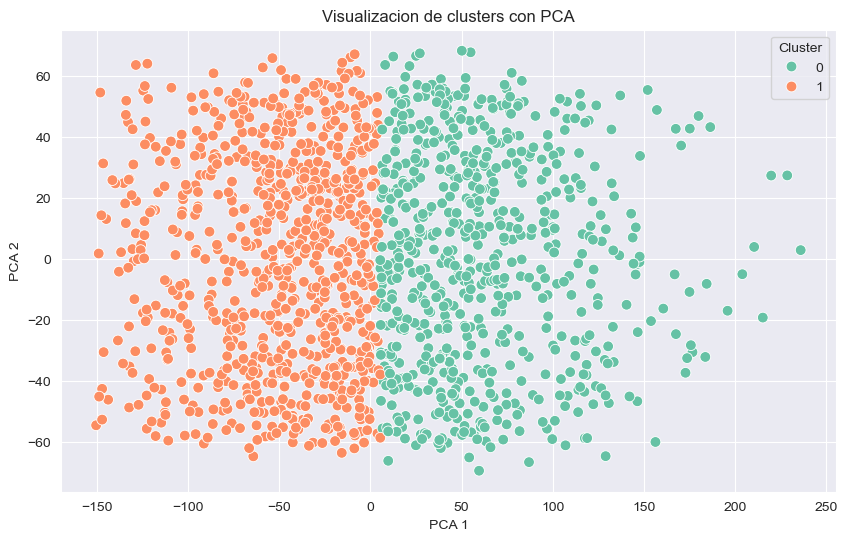

Imputacion completada.


In [9]:
columnas_cat_a_imputar = ['fumador', 'bebedor', 'diagnostico_diabetes']
columnas_num_a_imputar = ['edad', 'IMC', 'consumo_ultraprocesados']
data_imputada = imputar_por_kprototypes(data_tratada, columnas_cat_a_imputar,columnas_num_a_imputar)


Tipos de datos del DataFrame:


,Tipo de dato
id_paciente,int64
sexo,object
edad,float64
peso_kg,float64
altura_cm,float64
IMC,float64
grasa_corporal_pct,float64
masa_muscular_pct,float64
nivel_actividad,object
dias_ejercicio_semana,int64


Descripcion inicial de los datos:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_paciente,1500.0,NaN,NaN,NaN,750.5,1.0,375.75,750.5,1125.25,1500.0,433.157015
sexo,1500,4,Female,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad,1500.0,NaN,NaN,NaN,49.221333,1.0,22.0,48.5,78.0,104.0,31.017959
peso_kg,1500.0,NaN,NaN,NaN,70.901333,19.7,60.7,71.05,81.025,117.5,15.027302
altura_cm,1500.0,NaN,NaN,NaN,169.9638,136.1,162.9,169.75,177.0,205.0,10.027143
IMC,1500.0,NaN,NaN,NaN,25.139455,9.341281,22.028094,25.153739,28.255709,39.219737,4.787065
grasa_corporal_pct,1500.0,NaN,NaN,NaN,25.133067,5.0,18.2,25.1,31.7,59.1,9.694352
masa_muscular_pct,1500.0,NaN,NaN,NaN,35.112667,0.1,23.7,34.8,44.8,137.8,15.939588
nivel_actividad,1500,4,alto,513,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dias_ejercicio_semana,1500.0,NaN,NaN,NaN,4.418,0.0,2.0,4.0,7.0,9.0,2.855996


Distribucion inicial de variables numericas:


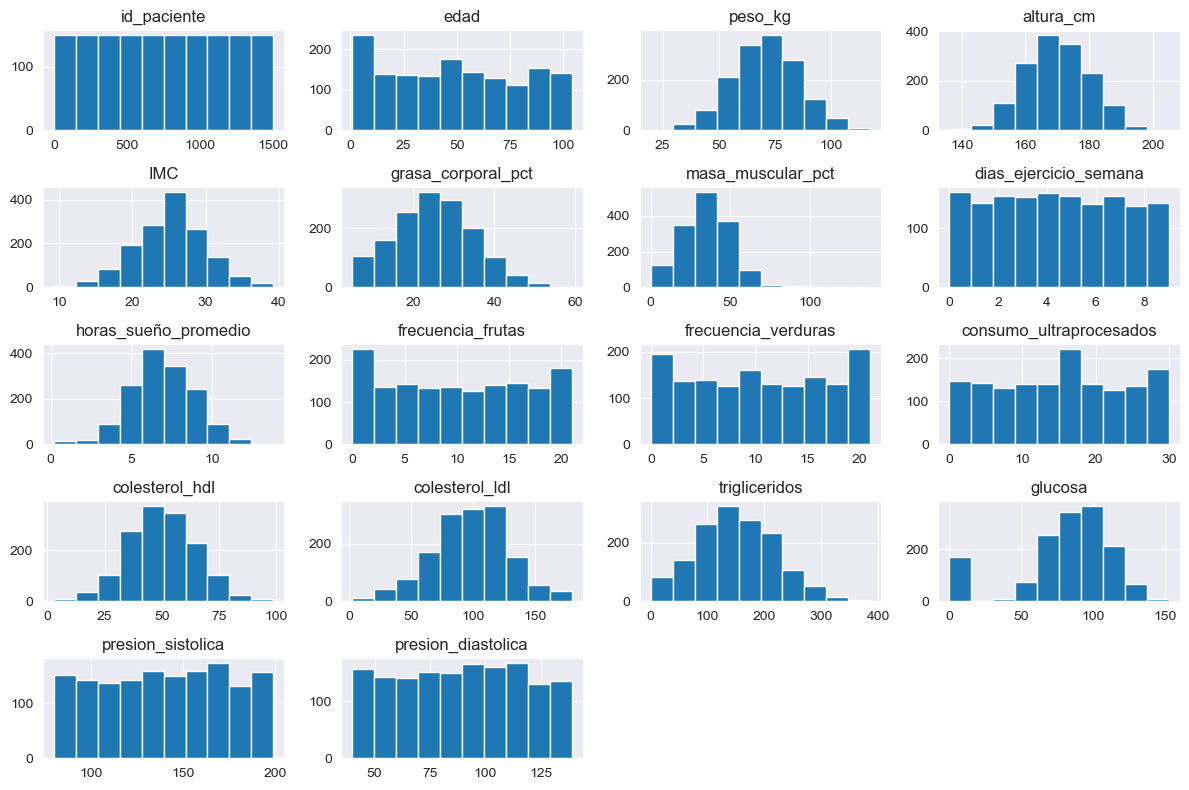

Distribucion de las variables categoricas:


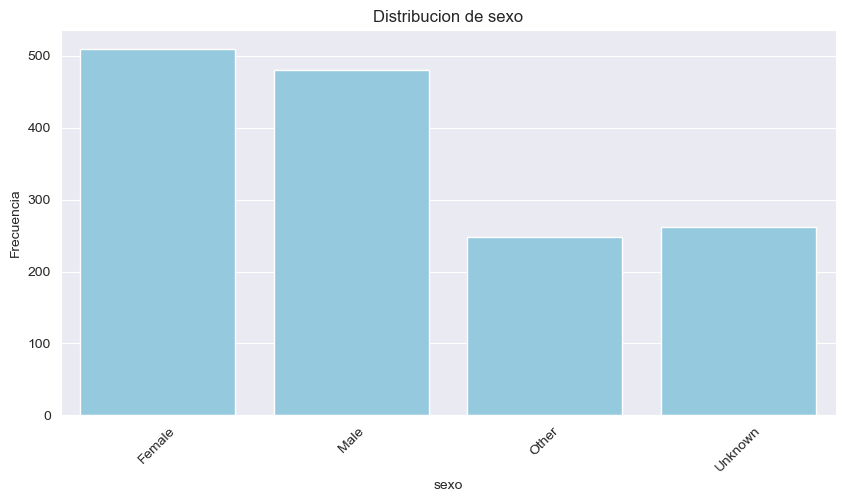

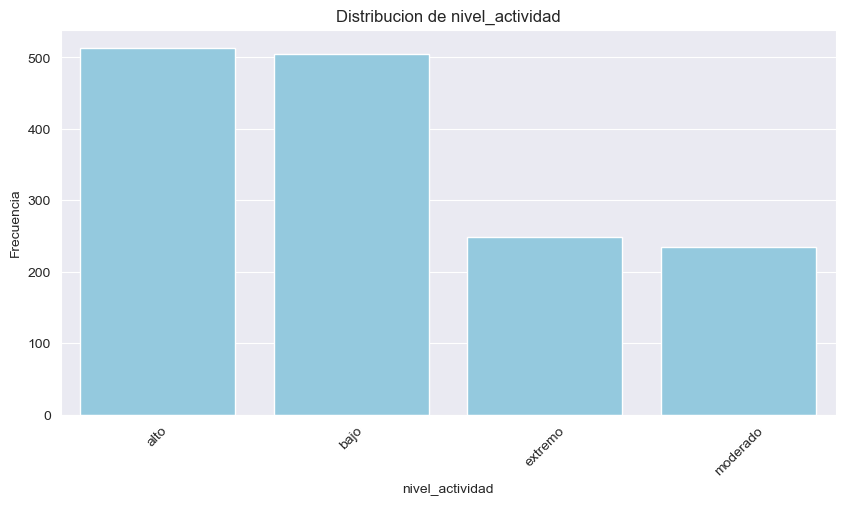

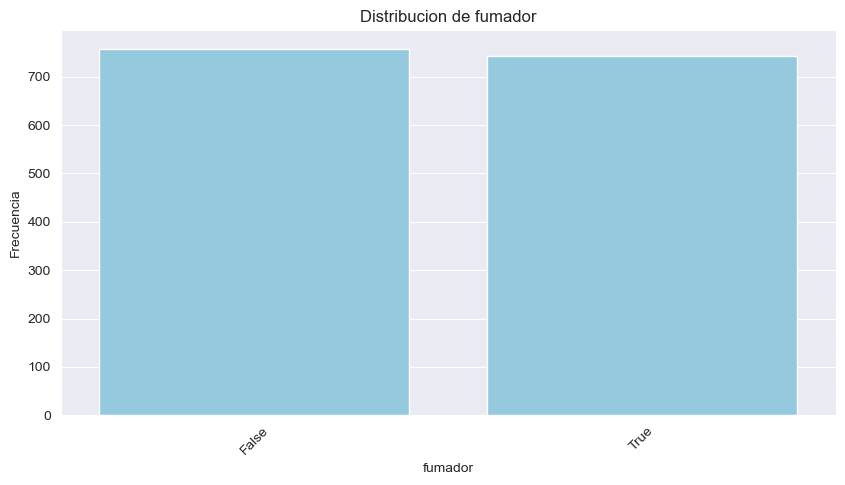

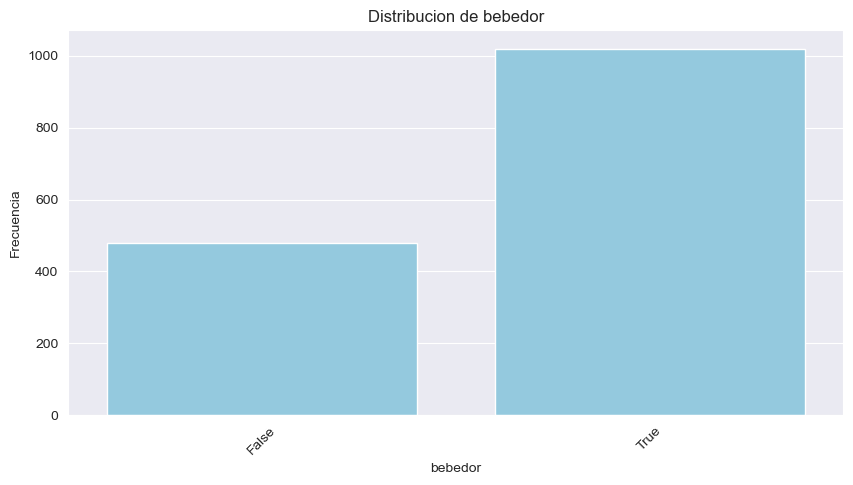

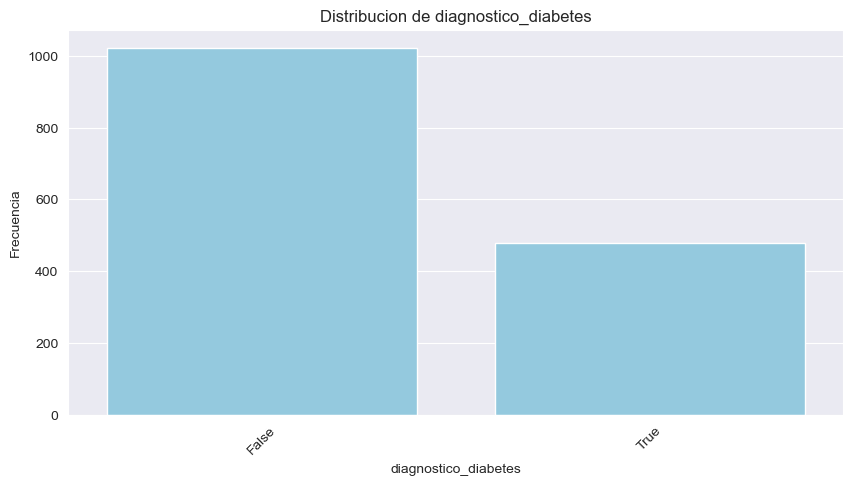

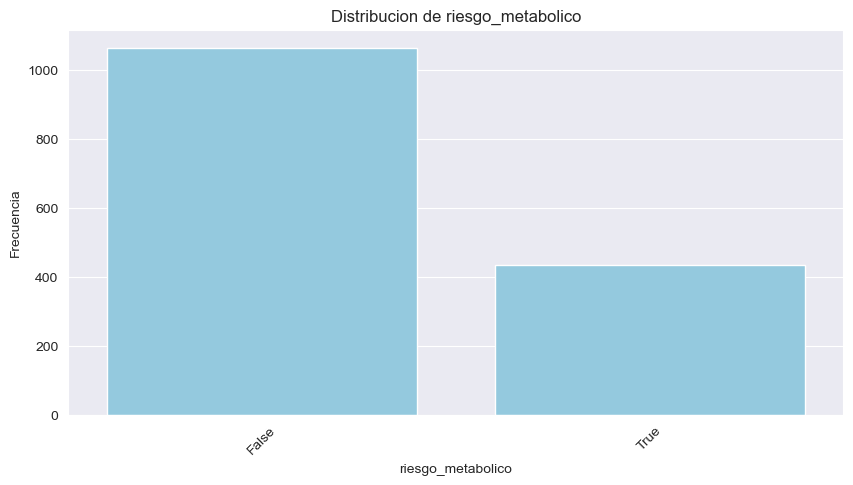

Estadisticas para columnas de tipo fecha:


,columna,no nulos,nulos,min,max,rango (dias),valores unicos
0,fecha_registro,1500,0,2024-01-06,2025-12-04,698,397


In [10]:
explorar_dataframe(data_imputada)

Dado que la distibución de varias variables categóricas cambia notablemente al ser imputadas, se utilizara la versión sin imputar para el análisis posterior.

# Respuestas a preguntas

In [11]:
#¿Cuántos pacientes tienen valores extremos en triglicéridos?
Q1 = data_tratada['trigliceridos'].quantile(0.25)
Q3 = data_tratada['trigliceridos'].quantile(0.75)
IQR = Q3 - Q1
outliers_trigliceridos = data_tratada[(data_imputada['trigliceridos'] < Q1 - 1.5 * IQR) | (data_tratada['trigliceridos'] > Q3 + 1.5 * IQR)]
num_outliers = len(outliers_trigliceridos)
print(f"Pacientes con triglicéridos extremos: {num_outliers}")



Pacientes con triglicéridos extremos: 7


In [12]:
#Proporción con glucosa en mmol/L (valor típico para mmol/L es < 100)
es_mmol = data_tratada['glucosa'] < 40  # Heurística común
proporcion_mmol = es_mmol.mean()
print(f"Proporción de pacientes con glucosa en mmol/L: {proporcion_mmol:.2%}")

Proporción de pacientes con glucosa en mmol/L: 11.87%


In [13]:
# Nueva variable útil: ratio triglicéridos / HDL
data_tratada['ratio_trig_hdl'] = data_tratada['trigliceridos'] / data_tratada['colesterol_hdl']
print("Ratio triglicéridos / HDL creado como nueva variable:")
display(data_tratada[['trigliceridos', 'colesterol_hdl', 'ratio_trig_hdl']].sample(15))

Ratio triglicéridos / HDL creado como nueva variable:


,trigliceridos,colesterol_hdl,ratio_trig_hdl
683,202.5,42.0,4.821429
688,115.6,51.1,2.262231
951,223.3,72.2,3.092798
155,222.0,67.6,3.284024
1444,230.5,53.9,4.276438
28,102.6,74.2,1.382749
1328,99.4,76.9,1.292588
968,150.9,63.7,2.368917
972,185.1,44.9,4.122494
71,63.5,67.6,0.939349
